# Задание
- Почитать про фильтр вашего варианта. - Нижних частот
- Найти подходящую реализацию (например, в библиотеке `scipy.signal`).
- Разобраться со значением всех агрументов используемой/ых функции/й.
- Реализовать фильтр.
- Используя данные из предыдущей лабораторной, осуществить фильтрацию сигнала. - ..\05_lab\data\lab5_data6.txt

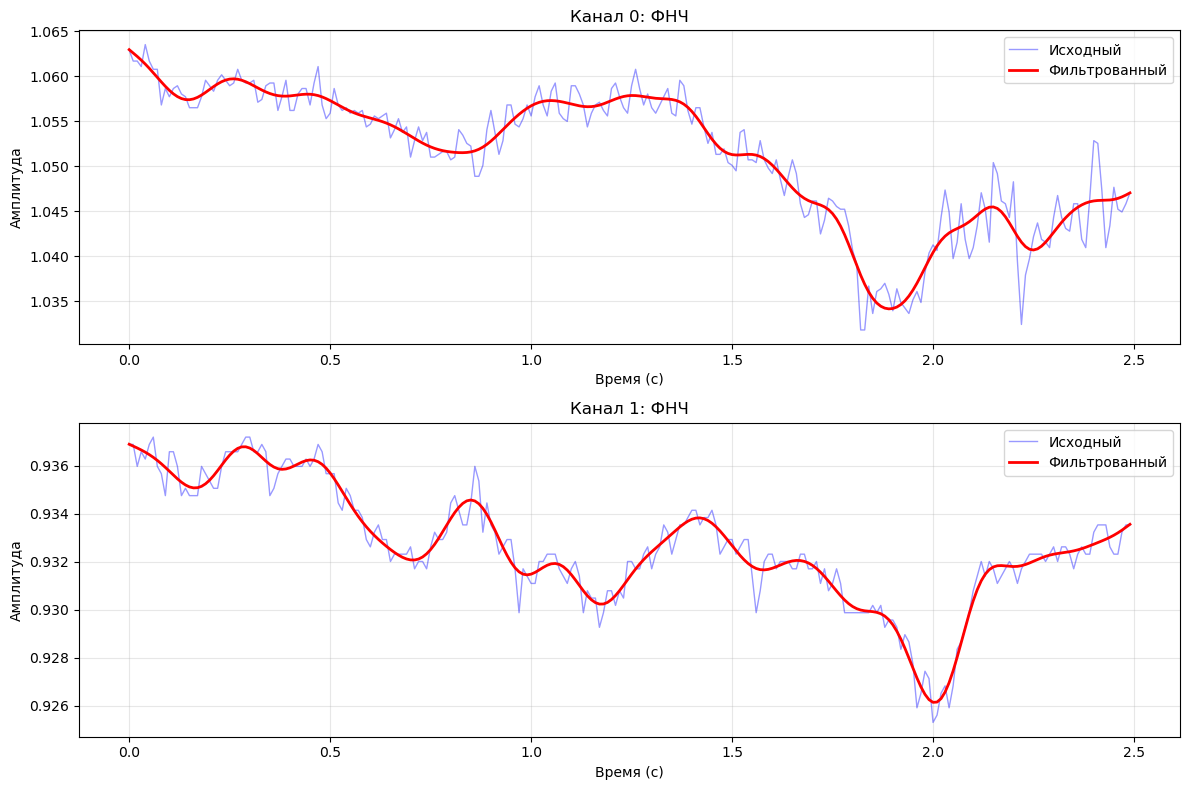

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

df = pd.read_csv("../05_lab/data/lab5_data6.txt", sep=';', usecols=['отсчеты', 'Канал0', 'Канал1'])

fs = 100.0 # частота дискретизации
t = df['отсчеты'].values / fs # преобразование в секунды
ch0 = df['Канал0'].values
ch1 = df['Канал1'].values

Fc = 6 # частота среза фильтра
# Всё, что медленнее 6 Гц (полезный сигнал) → пройдёт
# Всё, что быстрее 6 Гц (шум, помехи) → будет ослаблено

nyquist = fs / 2.0
# Частота Найквиста, Гц
# Максимальная частота, которую теоретически можно восстановить при данной частоте дискретизации.

Wn = Fc / nyquist
# Нормализованная частота среза (не в Герцах, а в долях)

b, a = signal.butter(
    4, # подрядок фильтра (среднее значение)
    Wn, # частота среза
    btype='low' # низкочастотный
)

ch0_filt = signal.filtfilt(b, a, ch0)
ch1_filt = signal.filtfilt(b, a, ch1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t, ch0, 'b-', alpha=0.4, linewidth=1)
axes[0].plot(t, ch0_filt, 'r-', linewidth=2)
axes[0].set_title(f'Канал 0: ФНЧ')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].legend(['Исходный', 'Фильтрованный'])
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, ch1, 'b-', alpha=0.4, linewidth=1)
axes[1].plot(t, ch1_filt, 'r-', linewidth=2)
axes[1].set_title(f'Канал 1: ФНЧ')
axes[1].set_xlabel('Время (с)')
axes[1].set_ylabel('Амплитуда')
axes[1].legend(['Исходный', 'Фильтрованный'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()